# Task 3: Customer Churn Prediction (Bank Customers)

________

## Problem Statement

The objective is to identify bank customers who are likely to leave (churn). Customer churn is costly
for banks — retaining existing customers is cheaper than acquiring new ones. We use the Churn
Modelling Dataset (available on Kaggle) which contains data on 10,000 bank customers including
geography, gender, age, balance, and whether they exited.

### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
classification_report)
%matplotlib inline
print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Load the Dataset

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Step 3: Dataset Understanding

In [3]:
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
df.describe()

# Check target column balance
print("Churn distribution (0=Stayed, 1=Left):")
print(df['Exited'].value_counts())
print(f"\nChurn rate: {df['Exited'].mean():.1%}")

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Statistical Summary:
Churn distribution (0=Stayed, 1=Left):
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.4%

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Es

### Step 4: Data Cleaning and Preparation

In [4]:
# Drop irrelevant identifier columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Remaining columns:", list(df.columns))
print("No missing values:", df.isnull().sum().sum() == 0)

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
No missing values: True


### Step 5: Encode Categorical Features

- Label Encoding (for binary columns)

In [5]:
le = LabelEncoder()
# Gender has 2 values: Male=1, Female=0
df['Gender'] = le.fit_transform(df['Gender'])
print("Gender encoded:", df['Gender'].unique())

Gender encoded: [0 1]


- One-Hot Encoding (for multi-class columns)

         - Geography has 3 values. One-Hot creates a separate column for each value to avoid implying any order
           (France=0, Germany=1, Spain=2 would be misleading).

In [6]:
# One-Hot Encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
print("Columns after encoding:")
print(list(df.columns))
df.head()

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


### Step 6: Exploratory Data Analysis (EDA)

- Churn Rate by Geography

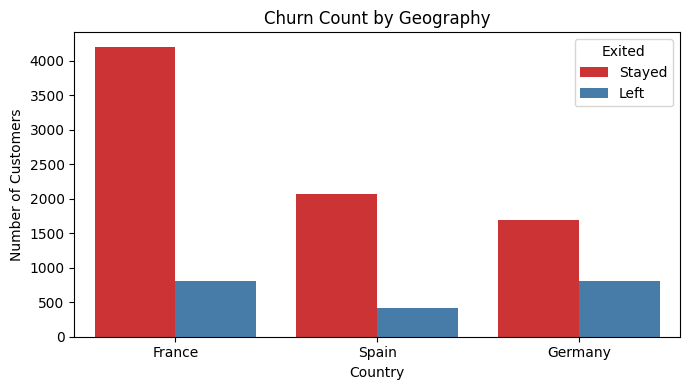

In [7]:
# Reload Geography before encoding for EDA
df_eda = pd.read_csv('Churn_Modelling.csv')
df_eda = df_eda.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

plt.figure(figsize=(7, 4))
sns.countplot(data=df_eda, x='Geography', hue='Exited', palette='Set1')
plt.title('Churn Count by Geography')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('churn_geography.png', dpi=150)
plt.show()

- Churn Rate by Gender

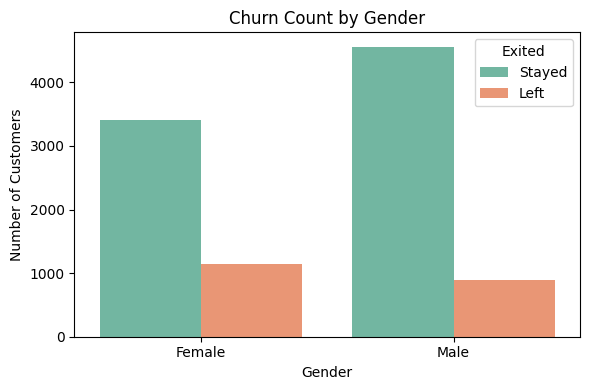

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x='Gender', hue='Exited', palette='Set2')
plt.title('Churn Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('churn_gender.png', dpi=150)
plt.show()

- Age Distribution by Churn

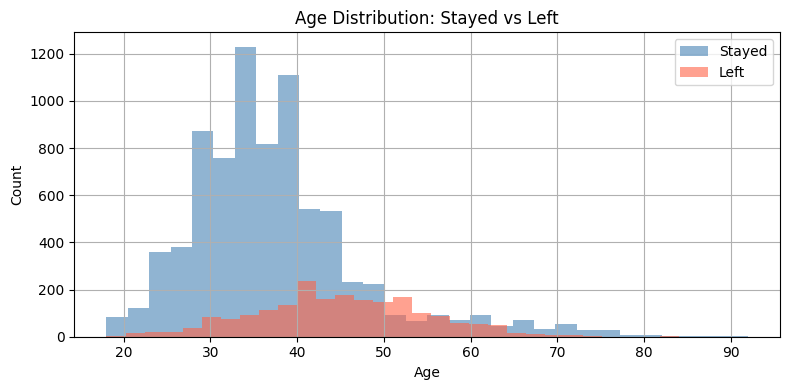

In [9]:
plt.figure(figsize=(8, 4))
df_eda[df_eda['Exited']==0]['Age'].hist(bins=30, alpha=0.6,
                                        label='Stayed', color='steelblue')

df_eda[df_eda['Exited']==1]['Age'].hist(bins=30, alpha=0.6,
                                        label='Left', color='tomato')

plt.title('Age Distribution: Stayed vs Left')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('churn_age.png', dpi=150)
plt.show()

- Balance by Churn

C:\Users\admin\AppData\Local\Temp\ipykernel_19016\3381062421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Exited', y='Balance', palette='Set1')


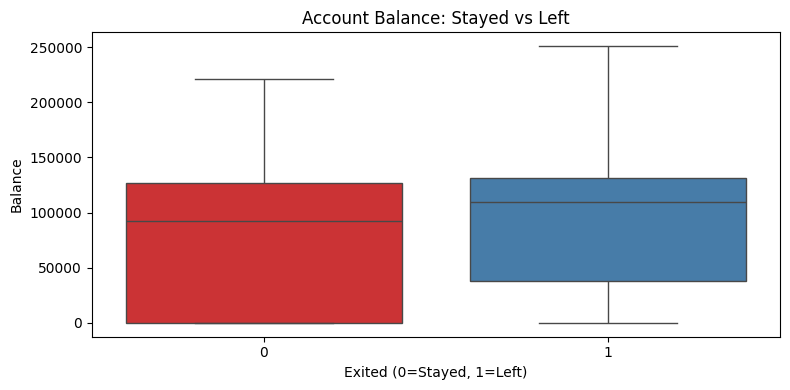

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_eda, x='Exited', y='Balance', palette='Set1')
plt.title('Account Balance: Stayed vs Left')
plt.xlabel('Exited (0=Stayed, 1=Left)')
plt.ylabel('Balance')
plt.tight_layout()
plt.savefig('churn_balance.png', dpi=150)
plt.show()

### Step 7: Prepare Features and Split Data

In [11]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print("Features:", list(X.columns))
print("Target: Exited")

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Target: Exited

Training samples: 8000
Testing samples: 2000


### Step 8: Scale Features

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")

Scaling complete!


### Step 9: Train Classification Models

- Model A — Random Forest

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Random Forest doesn't need scaling
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.2%}")

Random Forest Accuracy: 86.60%


- Model B — Logistic Regression

In [14]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train) # Use scaled data
lr_preds = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_acc:.2%}")

Logistic Regression Accuracy: 81.10%


### Step 10: Evaluate Models — Confusion Matrix

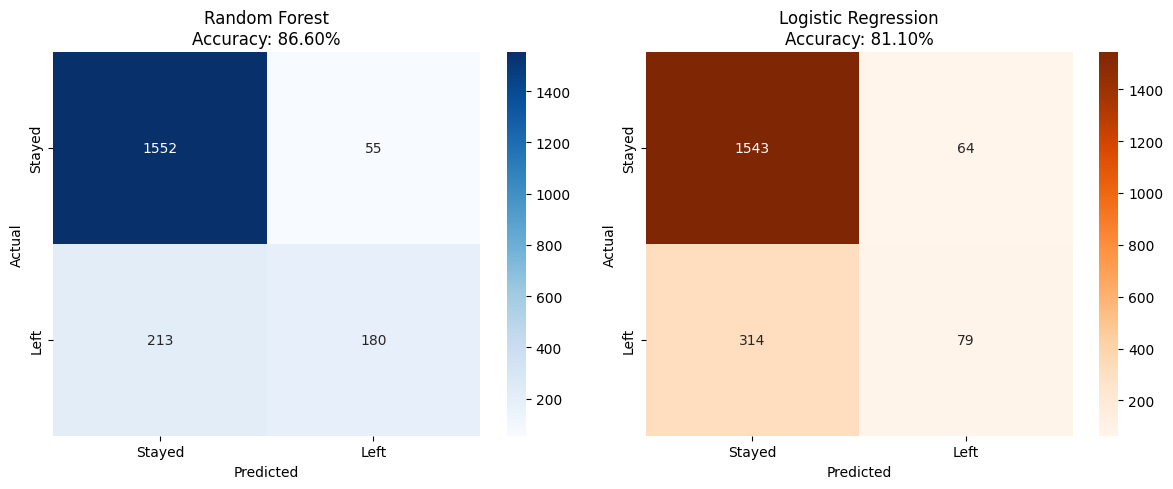

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Left'],
            yticklabels=['Stayed','Left'])

plt.title(f'Random Forest\nAccuracy: {rf_acc:.2%}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stayed','Left'],
            yticklabels=['Stayed','Left'])

plt.title(f'Logistic Regression\nAccuracy: {lr_acc:.2%}')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('churn_confusion_matrices.png', dpi=150)
plt.show()

### Step 11: Feature Importance Analysis

Feature Importances:
              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268


C:\Users\admin\AppData\Local\Temp\ipykernel_19016\3688860735.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


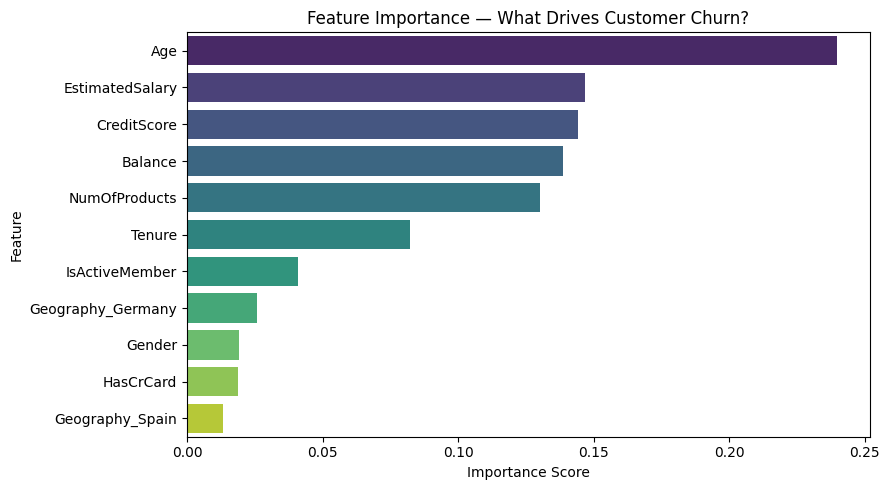

=== Random Forest Report ===
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1607
        Left       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [16]:
# Get feature importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a sorted DataFrame
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(feat_df)

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — What Drives Customer Churn?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# Full classification report
print("=== Random Forest Report ===")
print(classification_report(y_test, rf_preds,
                            target_names=['Stayed', 'Left']))

### Step 12: Conclusion — Key Insights

• **Churn rate** is around 20% — the dataset is imbalanced (more stayed than left).

• **Age** is typically the most important feature — older customers churn more.

• **Germany** has a significantly higher churn rate than France and Spain.

• **Customers** with higher balance are actually more likely to churn.

• **Female customers churn** at a slightly higher rate than male customers.

• **Random Forest** typically achieves ~86% accuracy on this dataset.

• **Feature importance** helps the bank focus retention efforts on the right customers.

________